[ 6153.87369124  3757.28112313 19801.13022094]
0.00063079
[ 3.88180199  2.37005536 12.49035493]
F1_array shape: (3,)


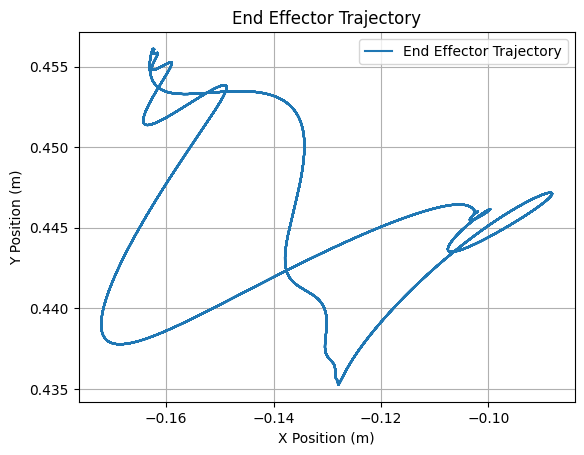

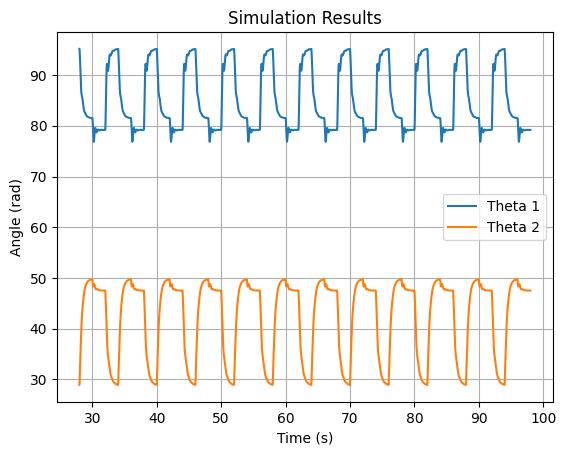

In [4]:
import mujoco
import datetime
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time

path = "../../../models/v2_4/urdf/dog2_4singleLeg_realconstrast.xml"

ExpName = f"AtoB_realsim_constrast_{datetime.datetime.now().strftime('%Y%m%d%H%M%S')}"
m = mujoco.MjModel.from_xml_path(path)
d = mujoco.MjData(m)

RB_BAA_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_BAA_SlideJoint")
RB_BAA_FM_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_BAA_FM_SlideJoint")
RB_MAA_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_MAA_SlideJoint")
RB_MAA_FM_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_MAA_FM_SlideJoint")
RB_shoulder_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_shoulder")
RB_Elbow_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_Elbow")

# Tools: 计算长度偏置（初始长度-原长）
def l_calulator(theta_1, theta_2):
    a_1 = 0.25
    a_2 = 0.25
    b_1 = 0.21213
    b_2 = 0.1
    d_1 = 0.06
    d_2 = 0.10

    # 角度参数 (度转弧度)
    beta_1 = 8.13 / 180 * np.pi
    beta_2 = 30 / 180 * np.pi

    A_x_O = d_1
    A_y_O = 0

    B_x_O = -d_2
    B_y_O = 0

    C_x_O = b_1 * np.cos(theta_1 - beta_1)
    C_y_O = b_1 * np.sin(theta_1 - beta_1)

    D_x_O = a_1 * np.cos(theta_1) + b_2 * np.cos(theta_1 + theta_2 + beta_2)
    D_y_O = a_1 * np.sin(theta_1) + b_2 * np.sin(theta_1 + theta_2 + beta_2)

    # 计算长度 l1 和 l2
    l_1 = np.sqrt((A_x_O - C_x_O)**2 + (A_y_O - C_y_O)**2)
    l_2 = np.sqrt((B_x_O - D_x_O)**2 + (B_y_O - D_y_O)**2)

    return l_1, l_2

# Tools: 计算驱动器设置初始偏置 (geom 模型)
def bias_calculator(l_10, l_20):
  l_1, l_2 = l_calulator(math.pi/2, math.pi/2)
  l1_rel = l_10 - l_1
  l2_rel = l_20 - l_2
  return l1_rel/2, l2_rel/2


P1_array = np.array([6.153873691241822, 3.757281123127819, 19.801130220938756])*1000
P2_array = np.array([2.7282463188213035, 7.2611504152265525, 8.519687913683074])*1000

viewer_flag = 0

def run_single_experiment(params, P1_array=P1_array, P2_array=P2_array, time_exp = 100, time_step = 2):
    """
    单次实验运行函数
    :param params: 包含(damping_MAA, damping_BAA, exp_id)的元组
    """
    try:
        stiffness_MAA, stiffness_BAA, l10, l20, damping_MAA, damping_BAA, s1, s2, c1_thigh, c2_calf = params
        
        m = mujoco.MjModel.from_xml_path(path)
        d = mujoco.MjData(m)
        print(P1_array)
        print(s1)

        F1_array = P1_array * s1
        F2_array = P2_array * s2
        print(F1_array)
        print(f"F1_array shape: {F1_array.shape}")

        # 设置刚度和阻尼
        for joint_id, stiffness, damping in zip(
            [RB_BAA_SlideJoint_id, RB_BAA_FM_SlideJoint_id, RB_MAA_SlideJoint_id, RB_MAA_FM_SlideJoint_id],
            [stiffness_BAA, stiffness_BAA, stiffness_MAA, stiffness_MAA],
            [damping_BAA, damping_BAA, damping_MAA, damping_MAA]
        ):
            m.jnt_stiffness[joint_id] = stiffness * 2
            m.dof_damping[joint_id] = damping * 2

        MAA_bias, BAA_bias = bias_calculator(l10, l20)
        for joint_id, bias in zip(
            [RB_BAA_SlideJoint_id, RB_BAA_FM_SlideJoint_id, RB_MAA_SlideJoint_id, RB_MAA_FM_SlideJoint_id],
            [BAA_bias, BAA_bias, MAA_bias, MAA_bias]
        ):
            m.qpos_spring[joint_id] = bias

        m.dof_damping[RB_shoulder_id] = c1_thigh
        m.dof_damping[RB_Elbow_id] = c2_calf

        d.ctrl = np.zeros_like(d.ctrl)
        mujoco.mj_step(m, d)

        # Experiment Settings
        ExpResultList = []
        

        start = time.time() if viewer_flag else d.time
        i = 0
        try:
            # if viewer_flag:
            #   with mujoco.viewer.launch_passive(m, d) as viewer:
                while (d.time - start) < time_exp:  # viewer.is_running() and
                    step_time = time.time() if viewer_flag else d.time

                    i = int((d.time - start)//time_step)
                    d.ctrl[:2] = F1_array[i%3]
                    d.ctrl[2:] = F2_array[i%3]
                    # elif time_step <= elapsed_time < time_exp:  # 稳定时间
                    #     d.ctrl[:] = 0  # 同时将所有控制信号置为0

                    # Trick: 由于实际数据稳定，所以这里只记录10s后的模拟数据，如果开始不收敛一定10s后的误差也很大
                    Position = np.array(d.qpos)
                    res = np.hstack((d.time, Position))
                    ExpResultList.append(res)

                    mujoco.mj_step(m, d)  # update!
                    if viewer_flag:
                      # 获取物理状态的更改，应用扰动，从GUI更新选项。
                    #   viewer.sync()   # TODO
                      # 粗略的计时，相对于挂钟会有漂移。
                      time_until_next_step = m.opt.timestep - (time.time() - step_time)
                      if time_until_next_step > 0:
                        time.sleep(time_until_next_step)

        # # 按住ctrl C退出循环
        except KeyboardInterrupt:
            pass
        
        # data process
        result_array = np.array(ExpResultList)
        time_sim = result_array[:,0]-time_step
        theta1_sim = (result_array[:,1]+math.pi/2)*180/np.pi
        theta2_sim = (result_array[:,2]+math.pi/2)*180/np.pi
        return time_sim, theta1_sim, theta2_sim
    
    except Exception as e:
        print(f"Error: {e}")
        raise e
    

k1 = 385.1225
k2 = 335.4172
l10 = 0.1862
l20 = 0.2709
c1 = 24.1515
c2 = 10.3101
s1 = 0.00063079
s2 = 0.00060325
c1_thigh = 4.9746
c2_calf = 0.3958
para = [k1, k2, l10, l20, c1, c2, s1, s2, c1_thigh, c2_calf]

time_sim, theta1_sim, theta2_sim = run_single_experiment(para, P1_array, P2_array, time_exp=100, time_step=2)

a_1 = 0.25
a_2 = 0.25
x_pos = a_1*np.cos(theta1_sim*math.pi/180) + a_2*np.cos(theta1_sim*math.pi/180 + theta2_sim*math.pi/180)
y_pos = a_1*np.sin(theta1_sim*math.pi/180) + a_2*np.sin(theta1_sim*math.pi/180 + theta2_sim*math.pi/180)
# Plotting the results
plt.figure()
slice_start = 6000  # 6s
plt.plot(x_pos[slice_start:], y_pos[slice_start:], label='End Effector Trajectory')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('End Effector Trajectory')
plt.legend()
plt.grid()


plt.figure()
plt.plot(time_sim[slice_start:], theta1_sim[slice_start:], label='Theta 1')
plt.plot(time_sim[slice_start:], theta2_sim[slice_start:], label='Theta 2')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('Simulation Results')
plt.legend()
plt.grid()
plt.show()

In [5]:
import mediapy as media

def videolize():
  # 尝试绘制视频
  duration = 10  # (seconds)
  framerate = 60  # (Hz)
  height = 320
  width = 400

  # Simulate and display video.
  frames = []
  model = mujoco.MjModel.from_xml_path(path)
  data = mujoco.MjData(model)

  mujoco.mj_resetData(model, data)  # Reset state and time.
  with mujoco.Renderer(model, height, width) as renderer:
    # Adjust the render resolution
    # renderer.set_quality(4)  # Use higher quality level
    while data.time < duration:
      # print(f"Time: {data.time:.2f}s")
      # mujoco.mj_step(model, data)
      data.ctrl[:2] = np.sin(data.time) * 10
      data.ctrl[2:] = np.cos(data.time) * 10
      mujoco.mj_step(model, data)
          
      if len(frames) < data.time * framerate:
        renderer.update_scene(data, camera="closeup")
        pixels = renderer.render()
        frames.append(pixels)
    return frames

  # media.show_video(frames, fps=framerate)

# %timeit -r 5 -n 10 videolize()


In [6]:
frames = videolize()
media.write_video("output_video.mp4", frames, fps=60)

In [9]:
# 导入真实数据（1.20）TriStatic_2025-01-21_19-26-44_A2B_data.csv
# 读取 CSV 文件
import pandas as pd
import os
import csv

tri_real_data = pd.read_csv("../../../log/TriStatic_2025-01-21_19-26-44_A2B_data.csv")
print(tri_real_data)

      relative_time  pressure1_start  pressure2_start  pressure1_end  \
0          0.016814      6153.873691      2728.246319    3757.281123   
1          0.027337      6153.873691      2728.246319    3757.281123   
2          0.037337      6153.873691      2728.246319    3757.281123   
3          0.048337      6153.873691      2728.246319    3757.281123   
4          0.059337      6153.873691      2728.246319    3757.281123   
...             ...              ...              ...            ...   
5697       1.956875     19801.130221      8519.687914    6153.873691   
5698       1.966875     19801.130221      8519.687914    6153.873691   
5699       1.976875     19801.130221      8519.687914    6153.873691   
5700       1.987870     19801.130221      8519.687914    6153.873691   
5701       1.998870     19801.130221      8519.687914    6153.873691   

      pressure2_end    base_x    base_y  base_theta10  thigh_theta20  \
0       7261.150415  0.253863  0.589171      0.283078      74.1

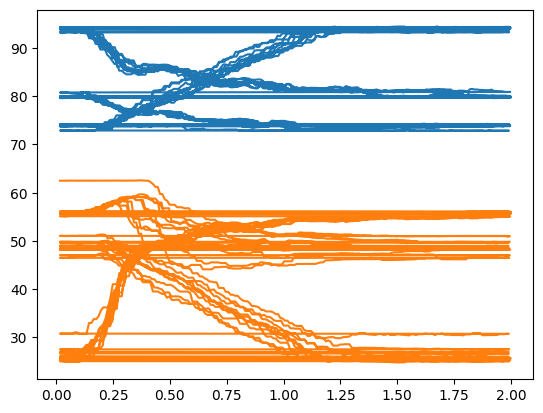

In [10]:
# 对比数据
time_real = tri_real_data['relative_time'].values    # 注意只有零到2的hhh
theta1_real = tri_real_data['thigh_theta21'].values
theta2_real = tri_real_data['calf_theta32'].values


data_length = 100000

plt.plot(time_real[:data_length], theta1_real[:data_length], label='Real Theta 1')
plt.plot(time_real[:data_length], theta2_real[:data_length], label='Real Theta 2')

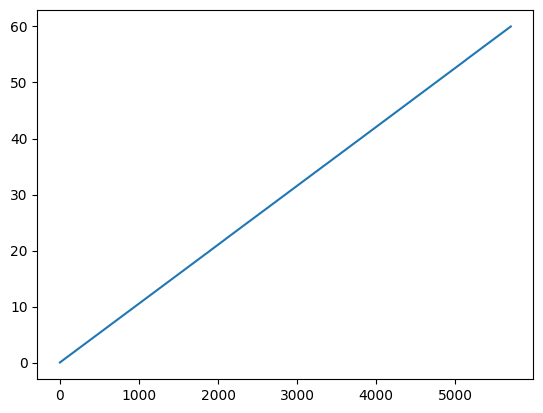

In [11]:
# 重构时间序列
for i in range(len(time_real)-1):
    if time_real[i+1] < time_real[i]:
        time_real[i+1] += int((time_real[i] - time_real[i+1])//2)*2 + 2
plt.plot(time_real[:data_length])

RMSE_theta1: 5.5883922020353545 
 RMSE_theta2: 7.847742533488727 
 MAE_theta1: 3.67833503084354 
 MAE_theta2: 5.924734634144488 
 MaxAE_theta1: 18.12570917484966 
 MaxAE_theta2: 27.003145943321968


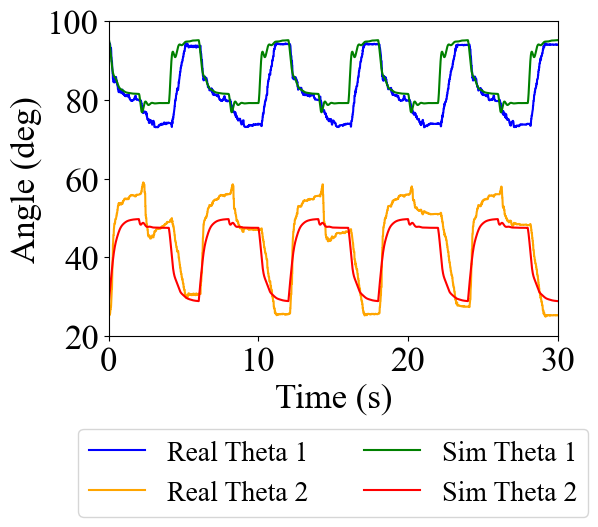

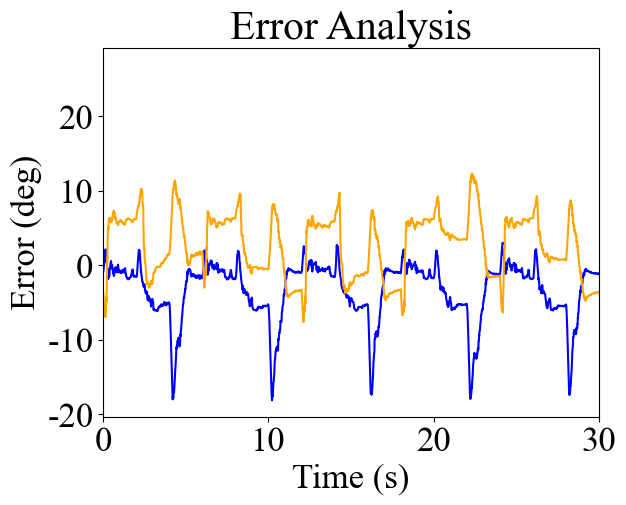

In [35]:
time_bias = time_sim[slice_start]
from matplotlib import rcParams

config = {
    "font.family":'Times New Roman',  # 设置字体类型
    "axes.unicode_minus": False, #解决负号无法显示的问题
    "font.size": 25,  # 设置字体大小
}
rcParams.update(config)

legendSet = {
    'loc': 'upper right',
    'fontsize': 15,
}

time_real_consider = time_real[:data_length]-time_bias
time_sim_consider = time_sim[slice_start:]-time_bias
theta1_real_consider = theta1_real[:data_length]
theta2_real_consider = theta2_real[:data_length]
theta1_sim_consider = theta1_sim[slice_start:]
theta2_sim_consider = theta2_sim[slice_start:]

plt.plot(time_real_consider, theta1_real_consider, label='Real Theta 1', color='blue')
plt.plot(time_real_consider, theta2_real_consider, label='Real Theta 2', color='orange')
plt.plot(time_sim_consider, theta1_sim_consider, label='Sim Theta 1', color='green')
plt.plot(time_sim_consider, theta2_sim_consider, label='Sim Theta 2', color='red')

plt.xlabel('Time (s)')
plt.ylabel('Angle (deg)')
# plt.title('Triangular Open-Loop Trajectory Control')
plt.axis([0, 30, 20, 100])
plt.legend(loc='upper right')
plt.tight_layout()
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    frameon=True,
    fontsize=20,
    
)

# 计算误差: 0~40s 100Hz
time_consider = np.arange(0, 40, 0.01)
theta1_real_consider = np.interp(time_consider, time_real_consider, theta1_real_consider)
theta2_real_consider = np.interp(time_consider, time_real_consider, theta2_real_consider)
theta1_sim_consider = np.interp(time_consider, time_sim_consider, theta1_sim_consider)
theta2_sim_consider = np.interp(time_consider, time_sim_consider, theta2_sim_consider)
theta1_error = theta1_real_consider - theta1_sim_consider
theta2_error = theta2_real_consider - theta2_sim_consider
plt.figure()
plt.plot(time_consider, theta1_error, label='Theta 1 Error', color='blue')
plt.plot(time_consider, theta2_error, label='Theta 2 Error', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Error (deg)')
plt.xlim(0, 30)
plt.title('Error Analysis')
# tight layout


# # 三角形轨迹
# plt.figure()
# # x_real = 

# RMSE, MAE, MaxAE
RMSE_theta1 = np.sqrt(np.mean(theta1_error**2))
RMSE_theta2 = np.sqrt(np.mean(theta2_error**2))
MAE_theta1 = np.mean(np.abs(theta1_error))
MAE_theta2 = np.mean(np.abs(theta2_error))
MaxAE_theta1 = np.max(np.abs(theta1_error))
MaxAE_theta2 = np.max(np.abs(theta2_error))
print(f"RMSE_theta1: {RMSE_theta1} \n",
      f"RMSE_theta2: {RMSE_theta2} \n",
      f"MAE_theta1: {MAE_theta1} \n",
      f"MAE_theta2: {MAE_theta2} \n",
      f"MaxAE_theta1: {MaxAE_theta1} \n",
      f"MaxAE_theta2: {MaxAE_theta2}")

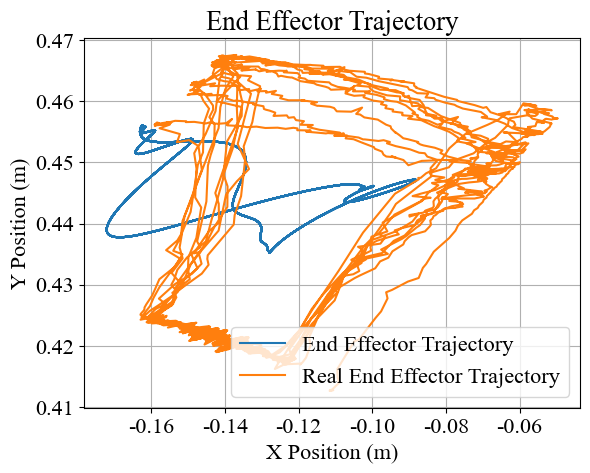

In [13]:

a_1 = 0.25
a_2 = 0.25
x_pos = a_1*np.cos(theta1_sim*math.pi/180) + a_2*np.cos(theta1_sim*math.pi/180 + theta2_sim*math.pi/180)
y_pos = a_1*np.sin(theta1_sim*math.pi/180) + a_2*np.sin(theta1_sim*math.pi/180 + theta2_sim*math.pi/180)
x_pos_real = a_1*np.cos(theta1_real*math.pi/180) + a_2*np.cos(theta1_real*math.pi/180 + theta2_real*math.pi/180)
y_pos_real = a_1*np.sin(theta1_real*math.pi/180) + a_2*np.sin(theta1_real*math.pi/180 + theta2_real*math.pi/180)
# Plotting the results
plt.figure()
slice_start = 6000  # 6s
plt.plot(x_pos[slice_start:], y_pos[slice_start:], label='End Effector Trajectory')
plt.plot(x_pos_real, y_pos_real, label='Real End Effector Trajectory')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('End Effector Trajectory')
plt.legend()
plt.grid()


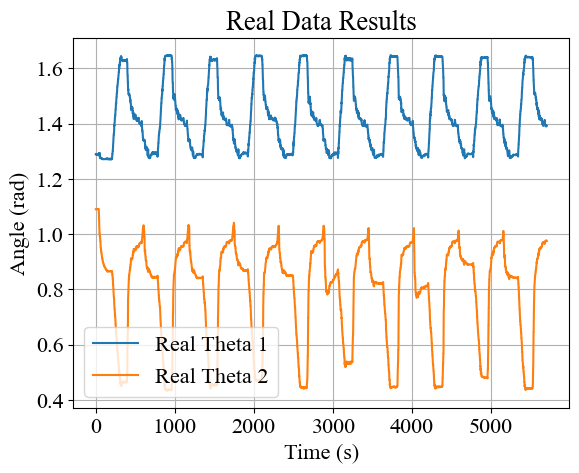

In [14]:
plt.plot(theta1_real*math.pi/180, label='Real Theta 1')
plt.plot(theta2_real*math.pi/180, label='Real Theta 2')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('Real Data Results')
plt.legend()
plt.grid()

KeyboardInterrupt: 

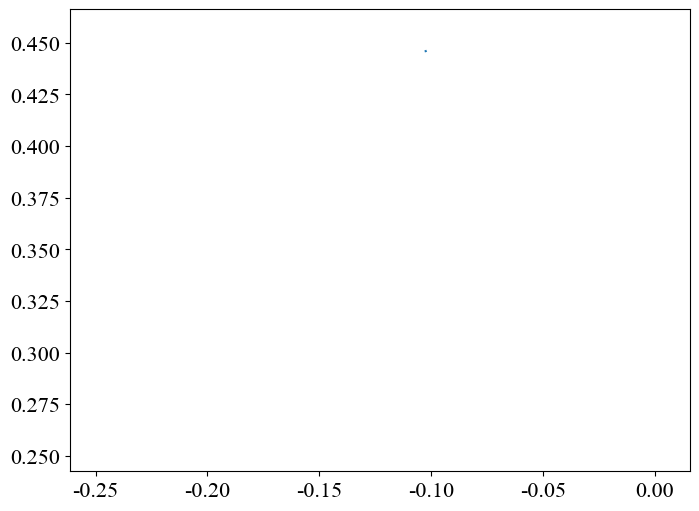

In [15]:
# 绘制动图
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# 创建示例数据
x = x_pos
y = y_pos

# 创建动画
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot(x, y)

def update(frame):
    line.set_data(x[frame+5000:frame+5000+10], y[frame+5000:frame+5000+10])
    return line,

ani_vi = animation.FuncAnimation(fig, update, frames=1000, interval=50, blit=True)

# 在Jupyter Notebook中显示动画
display(HTML(ani_vi.to_jshtml()))  # 将动画显示为HTML内容